<a href="https://colab.research.google.com/github/oluwap3lumi/Electricity-Anomaly-Detection/blob/main/ELECTRICITY_ANOMALIES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')
pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files

uploaded = files.upload()

# Load dataset
df = pd.read_csv('smart_meter_data (1).csv')


df.head()

Saving smart_meter_data (1).csv to smart_meter_data (1).csv


,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [3]:
print("Dataset shape:", df.shape)

# Column info
df.info()

# Summary stats
df.describe()

# Check missing values
df.isnull().sum().sort_values(ascending=False)

Dataset shape: (5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB


,0
Timestamp,0
Electricity_Consumed,0
Temperature,0
Humidity,0
Wind_Speed,0
Avg_Past_Consumption,0
Anomaly_Label,0


In [4]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.columns

Index(['timestamp', 'electricity_consumed', 'temperature', 'humidity',
       'wind_speed', 'avg_past_consumption', 'anomaly_label'],
      dtype='object')

In [5]:
# Convert to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort values
df = df.sort_values('timestamp')

# Set index (optional but powerful)
df.set_index('timestamp', inplace=True)

In [6]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Drop duplicates if needed
df = df.drop_duplicates()

# Check data ranges
df.describe(include='all')

Duplicates: 0


,electricity_consumed,temperature,humidity,wind_speed,avg_past_consumption,anomaly_label
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000
unique,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,Normal
freq,NaN,NaN,NaN,NaN,NaN,4750
mean,0.376677,0.525069,0.497632,0.464628,0.458738,NaN
std,0.164117,0.135603,0.146781,0.120370,0.146749,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.265349,0.434253,0.398956,0.382906,0.358857,NaN
50%,0.377244,0.524052,0.497539,0.464958,0.457814,NaN
75%,0.486002,0.617281,0.595359,0.547419,0.555607,NaN


In [7]:
#DATA ANALYSIS

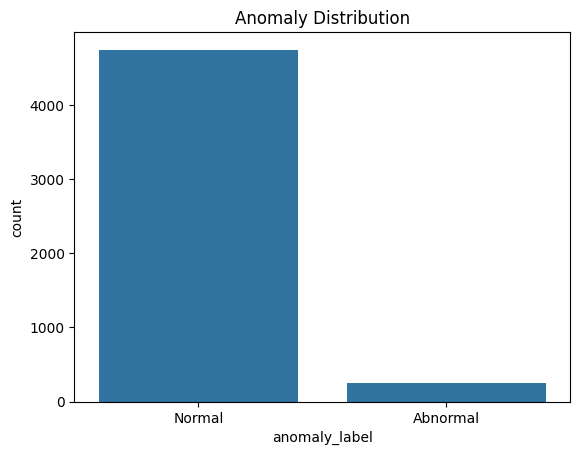

anomaly_label
Normal      0.95
Abnormal    0.05
Name: proportion, dtype: float64


In [10]:
sns.countplot(x=df['anomaly_label'])
plt.title("Anomaly Distribution")
plt.show()

print(df['anomaly_label'].value_counts(normalize=True))

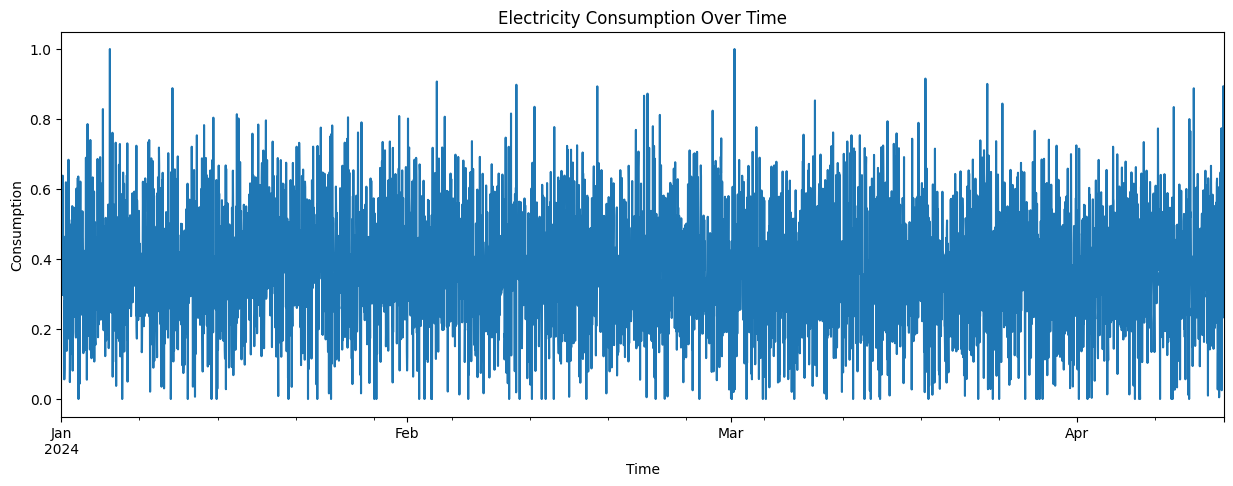

In [12]:
plt.figure(figsize=(15,5))
df['electricity_consumed'].plot()
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.show()

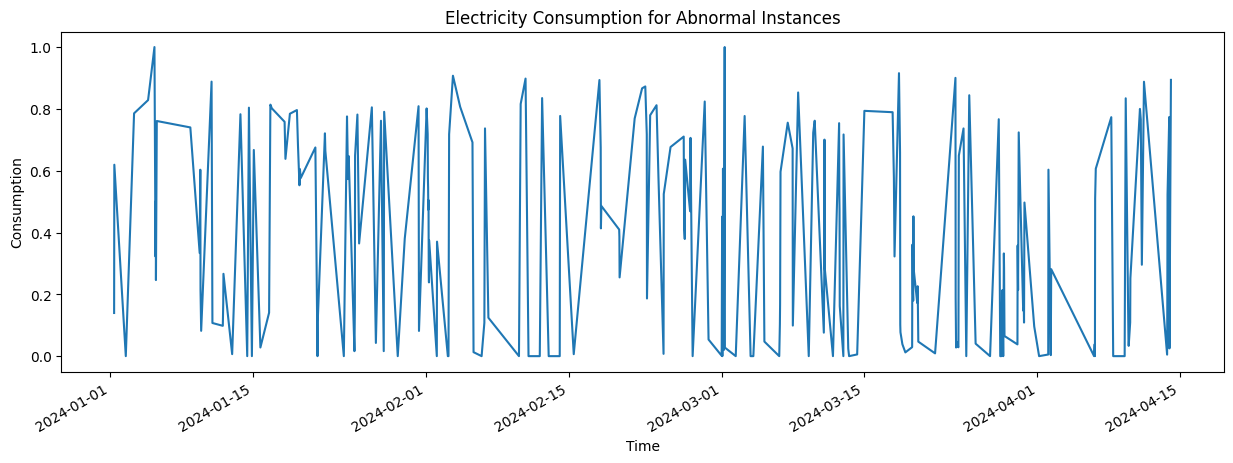

In [13]:
# Filter for 'Abnormal' instances
abnormal_consumption = df[df['anomaly_label'] == 'Abnormal']

plt.figure(figsize=(15, 5))
abnormal_consumption['electricity_consumed'].plot()
plt.title("Electricity Consumption for Abnormal Instances")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.show()

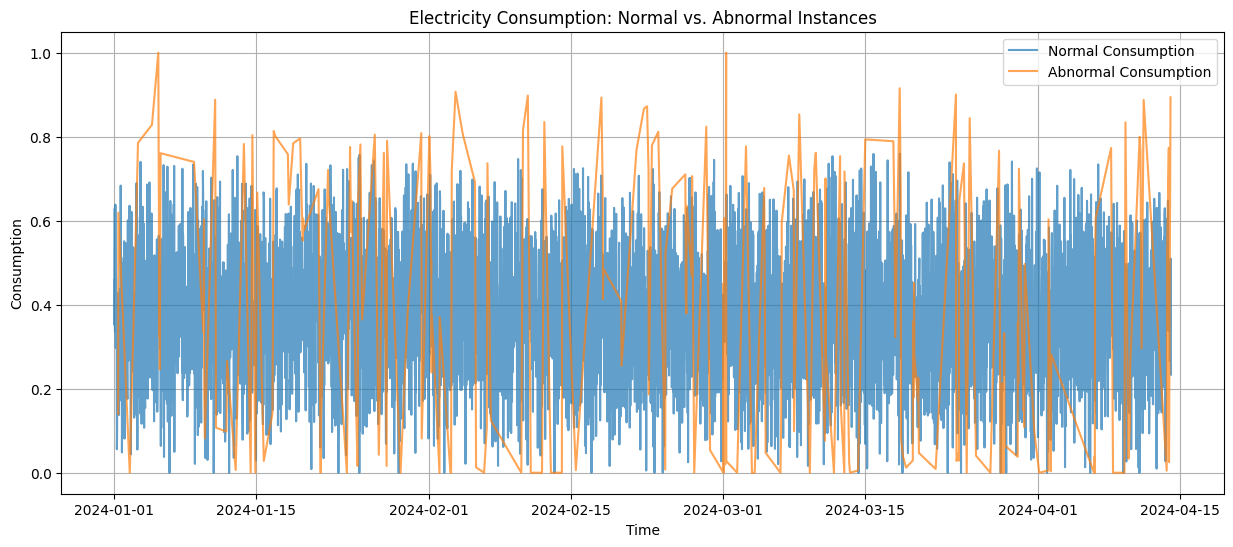

In [14]:
# Filter for 'Normal' instances
normal_consumption = df[df['anomaly_label'] == 'Normal']

plt.figure(figsize=(15, 6))
plt.plot(normal_consumption.index, normal_consumption['electricity_consumed'], label='Normal Consumption', alpha=0.7)
plt.plot(abnormal_consumption.index, abnormal_consumption['electricity_consumed'], label='Abnormal Consumption', alpha=0.7)
plt.title('Electricity Consumption: Normal vs. Abnormal Instances')
plt.xlabel('Time')
plt.ylabel('Consumption')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
avg_normal_consumption = normal_consumption['electricity_consumed'].mean()
avg_abnormal_consumption = abnormal_consumption['electricity_consumed'].mean()

print(f"Average Electricity Consumption for Normal Instances: {avg_normal_consumption:.4f}")
print(f"Average Electricity Consumption for Abnormal Instances: {avg_abnormal_consumption:.4f}")

Average Electricity Consumption for Normal Instances: 0.3766
Average Electricity Consumption for Abnormal Instances: 0.3790


/tmp/ipykernel_4979/3220926946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='anomaly_label', y=feature, data=df, palette='viridis')
/tmp/ipykernel_4979/3220926946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='anomaly_label', y=feature, data=df, palette='viridis')
/tmp/ipykernel_4979/3220926946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='anomaly_label', y=feature, data=df, palette='viridis')
/tmp/ipykernel_4979/3220926946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

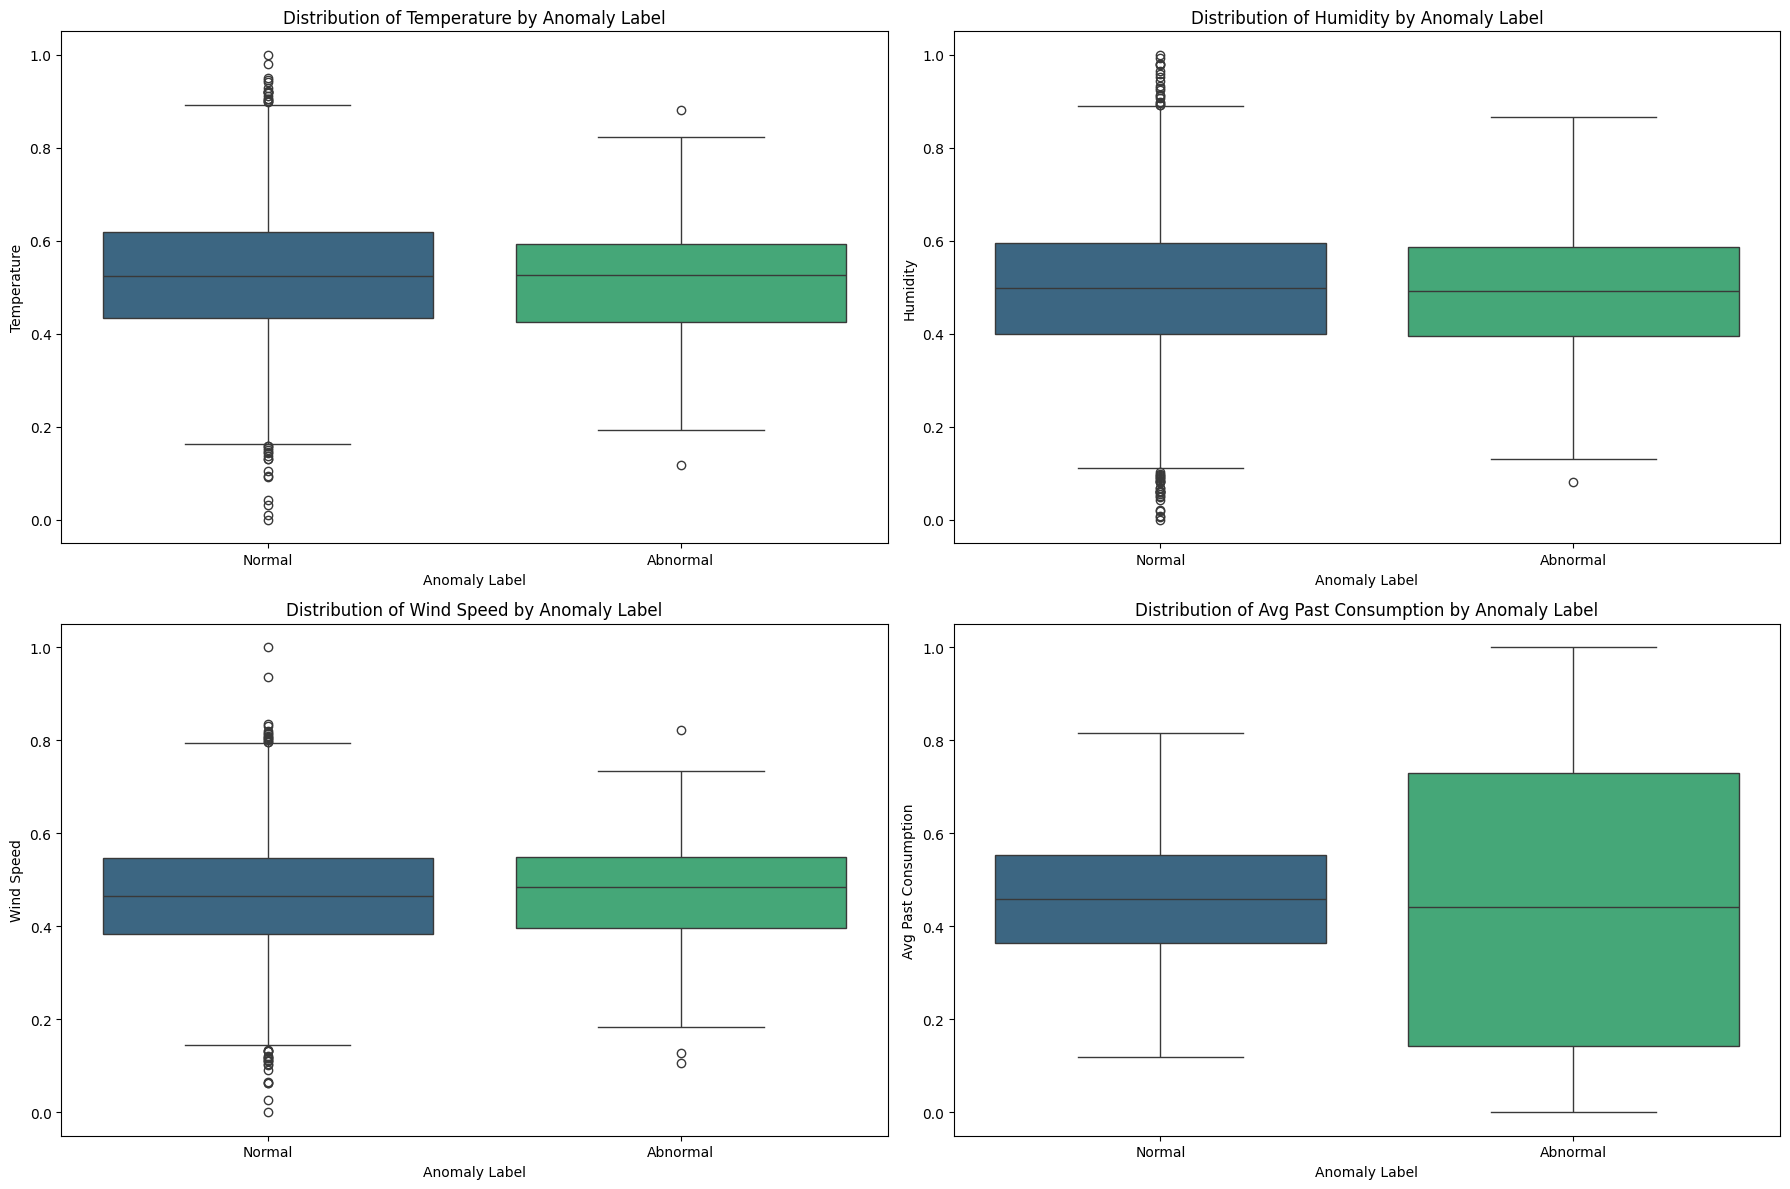

In [16]:
features_to_analyze = ['temperature', 'humidity', 'wind_speed', 'avg_past_consumption']

plt.figure(figsize=(18, 12))

for i, feature in enumerate(features_to_analyze):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(x='anomaly_label', y=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Anomaly Label')
    plt.xlabel('Anomaly Label')
    plt.ylabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

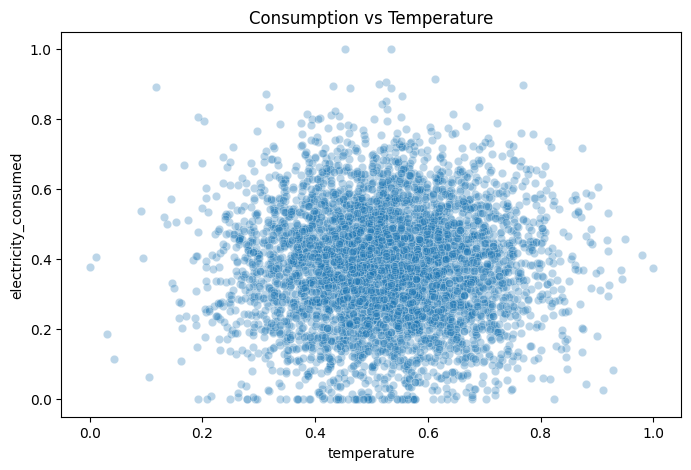

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['temperature'],
    y=df['electricity_consumed'],
    alpha=0.3
)
plt.title("Consumption vs Temperature")
plt.show()

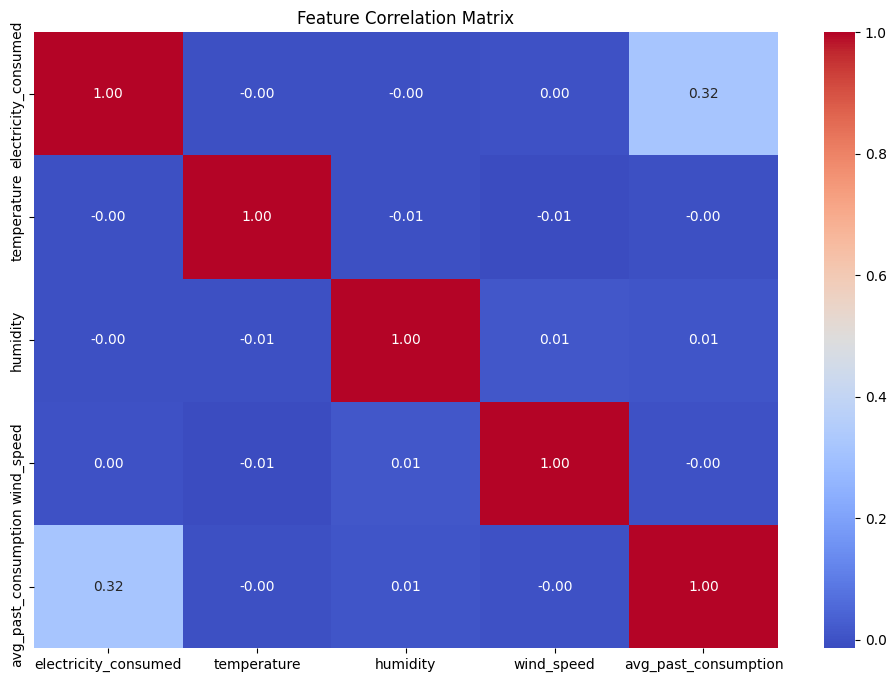

In [18]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

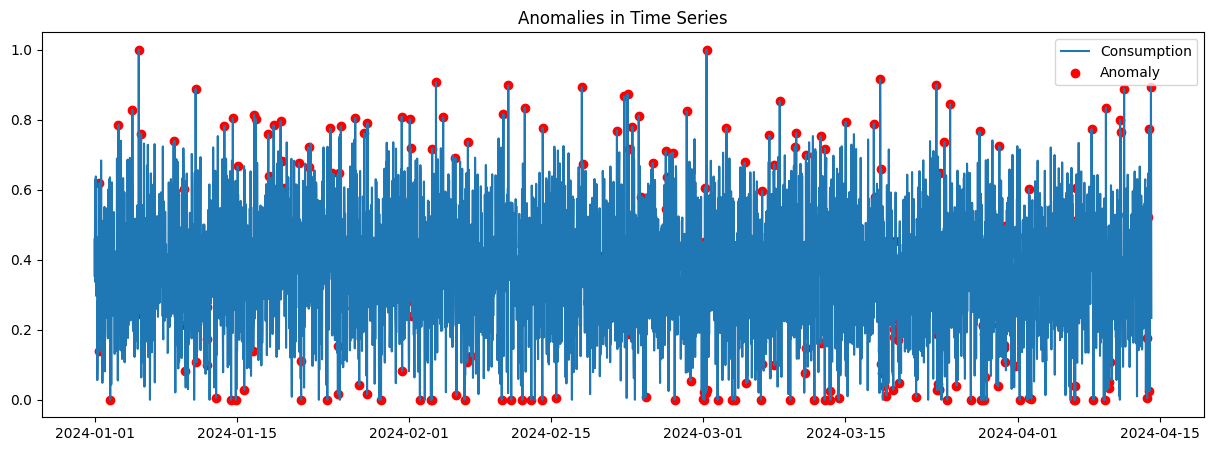

In [21]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df['electricity_consumed'], label='Consumption')

# Highlight anomalies
anomalies = df[df['anomaly_label'] == 'Abnormal'] # Change 1 to 'Abnormal' as Anomaly_Label contains 'Normal' and 'Abnormal'
plt.scatter(anomalies.index, anomalies['electricity_consumed'], color='red', label='Anomaly')

plt.legend()
plt.title("Anomalies in Time Series")
plt.show()

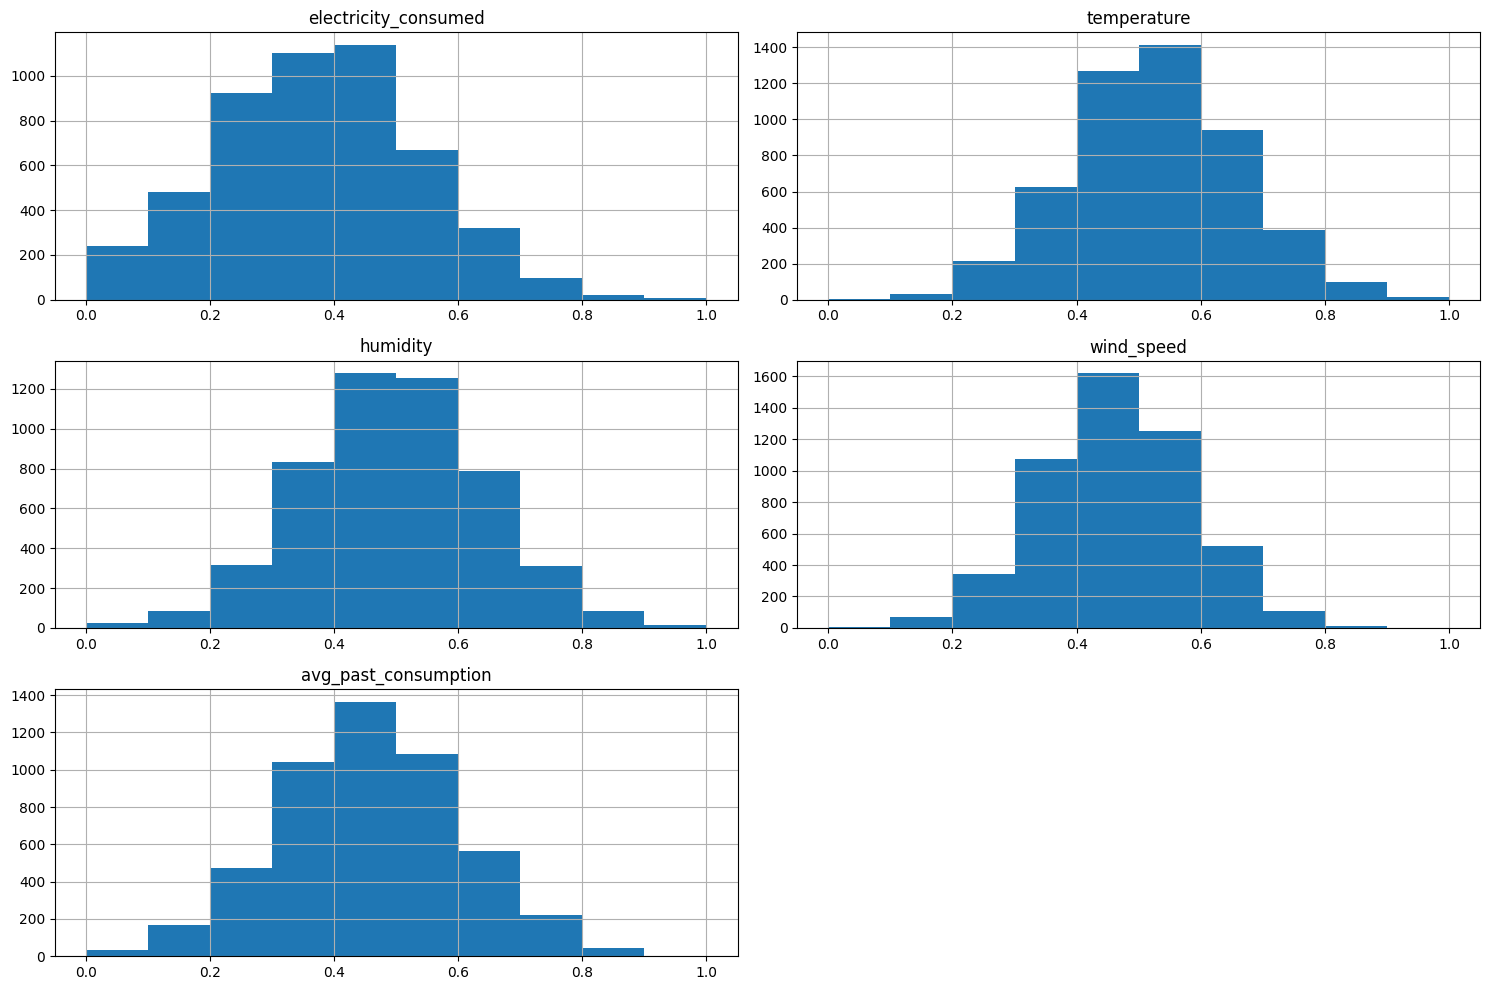

In [22]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [23]:
#FEATURE ENGINEERING:
#TIME BASED FEATURES
#LAG FEATURES
#ROLLING STATISTICS
#CONSUMPTION DYNAMICS
#WEATHER INTERACTION FEATURES
#ANOMALY AWARE FEATURE (for advanced insight)

In [24]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [26]:
df['lag_1'] = df['electricity_consumed'].shift(1)
df['lag_2'] = df['electricity_consumed'].shift(2)
df['lag_3'] = df['electricity_consumed'].shift(3)

In [27]:
lag_features = ['lag_1', 'lag_2', 'lag_3']
correlation_with_consumption = df[lag_features + ['electricity_consumed']].corr().loc['electricity_consumed', lag_features]
display(correlation_with_consumption)


,electricity_consumed
lag_1,-0.013560
lag_2,-0.006254
lag_3,-0.001927


This output shows the Pearson correlation coefficient between `electricity_consumed` and each of the lag features. A value close to 1 indicates a strong positive correlation, a value close to -1 indicates a strong negative correlation, and a value close to 0 indicates a weak or no linear correlation.

In [30]:
df['rolling_mean_3'] = df['electricity_consumed'].rolling(window=3).mean()
df['rolling_std_3'] = df['electricity_consumed'].rolling(window=3).std()

df['rolling_mean_6'] = df['electricity_consumed'].rolling(window=6).mean()
df['rolling_std_6'] = df['electricity_consumed'].rolling(window=6).std()

In [32]:
df['consumption_diff'] = df['electricity_consumed'].diff()

df['consumption_ratio'] = df['electricity_consumed'] / (df['rolling_mean_6'] + 1e-5)

In [33]:
df['temp_consumption_interaction'] = df['temperature'] * df['electricity_consumed']

df['humidity_consumption_interaction'] = df['humidity'] * df['electricity_consumed']

In [34]:
df['z_score'] = (
    (df['electricity_consumed'] - df['rolling_mean_6']) /
    (df['rolling_std_6'] + 1e-5)
)

In [35]:
df = df.dropna()

In [36]:
print("Final shape:", df.shape)
df.head()

Final shape: (4995, 22)


,electricity_consumed,temperature,humidity,wind_speed,avg_past_consumption,anomaly_label,hour,day_of_week,month,is_weekend,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,consumption_diff,consumption_ratio,temp_consumption_interaction,humidity_consumption_interaction,z_score
timestamp,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 02:30:00,0.335977,0.355389,0.382767,0.361111,0.618607,Normal,2,0,1,0,0.335974,0.628838,0.482948,0.433597,0.169084,0.432247,0.115632,0.000003,0.777263,0.119403,0.128601,-0.832477
2024-01-01 03:00:00,0.638202,0.667102,0.643164,0.611004,0.703225,Normal,3,0,1,0,0.335977,0.335974,0.628838,0.436718,0.174490,0.462316,0.143662,0.302225,1.380416,0.425746,0.410468,1.224217
2024-01-01 03:30:00,0.502906,0.591854,0.381205,0.407144,0.718050,Normal,3,0,1,0,0.638202,0.335977,0.335974,0.492362,0.151388,0.487474,0.133315,-0.135296,1.031635,0.297647,0.191710,0.115743
2024-01-01 04:00:00,0.296754,0.427858,0.371512,0.311121,0.663703,Normal,4,0,1,0,0.502906,0.638202,0.335977,0.479287,0.171945,0.456442,0.154558,-0.206152,0.650132,0.126969,0.110248,-1.033125
2024-01-01 04:30:00,0.465427,0.507400,0.616383,0.404446,0.668736,Normal,4,0,1,0,0.296754,0.502906,0.638202,0.421696,0.109813,0.429207,0.130652,0.168672,1.084363,0.236158,0.286881,0.277202


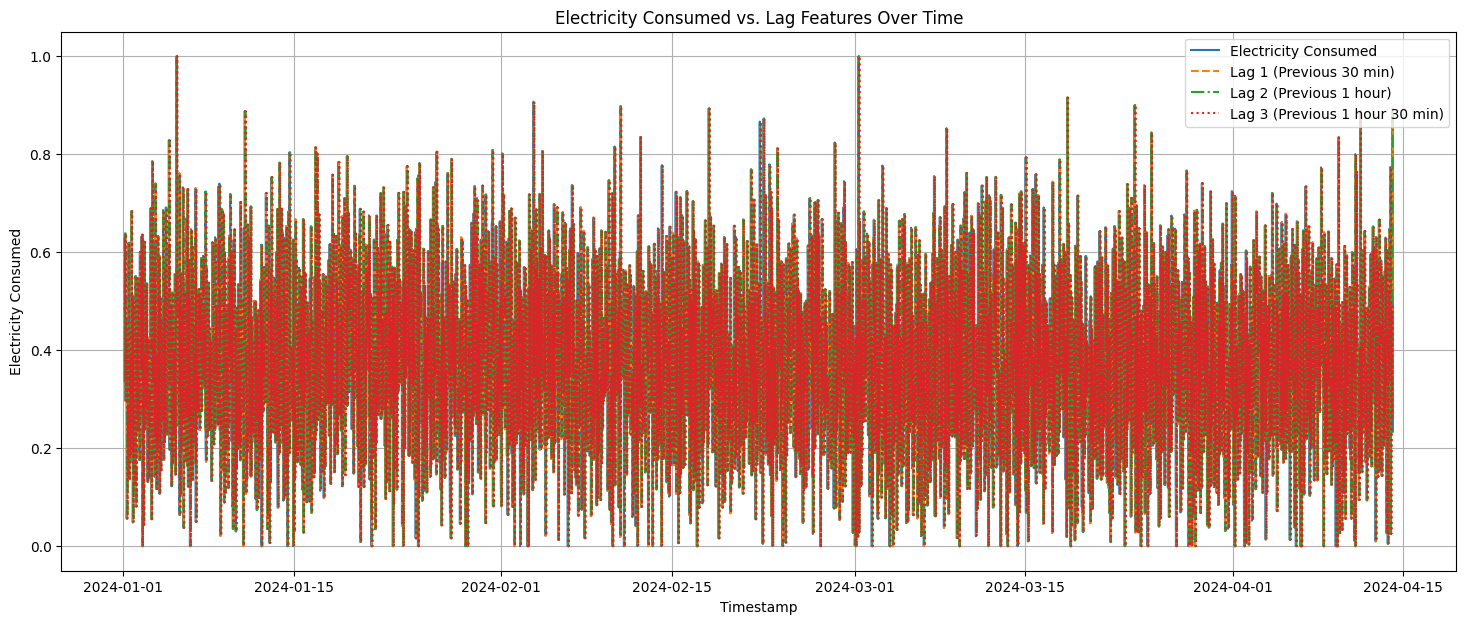

In [37]:
plt.figure(figsize=(18, 7))

plt.plot(df.index, df['electricity_consumed'], label='Electricity Consumed')
plt.plot(df.index, df['lag_1'], label='Lag 1 (Previous 30 min)', linestyle='--')
plt.plot(df.index, df['lag_2'], label='Lag 2 (Previous 1 hour)', linestyle='-.')
plt.plot(df.index, df['lag_3'], label='Lag 3 (Previous 1 hour 30 min)', linestyle=':')

plt.title('Electricity Consumed vs. Lag Features Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Electricity Consumed')
plt.legend()
plt.grid(True)
plt.show()

This plot shows the 'Electricity Consumed' over time along with its three lag features (lag_1, lag_2, and lag_3).

'Electricity Consumed' (blue line): Represents the actual electricity consumption at each timestamp.
Lag Features (dashed, dash-dot, and dotted lines): These lines show the electricity consumption from previous time steps:
lag_1: Consumption 30 minutes prior.
lag_2: Consumption 1 hour prior.
lag_3: Consumption 1 hour and 30 minutes prior.
What this plot tells us:

By observing the relationship between the main 'Electricity Consumed' line and the lag lines, you can visually assess the autocorrelation of the time series. If the lag lines closely follow the main consumption line (just shifted in time), it indicates a strong correlation between current consumption and past consumption. This means that past consumption values are good predictors of current consumption. For example, if consumption tends to be similar at the same time each day, you would see the lag lines mirroring the blue line but offset. This visual can help confirm the weak negative correlations we saw earlier between the lag features and current consumption, indicating that past consumption in this specific dataset doesn't strongly predict current consumption over these short time intervals.

In [38]:
display(df.describe())

,electricity_consumed,temperature,humidity,wind_speed,avg_past_consumption,hour,day_of_week,month,is_weekend,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,consumption_diff,consumption_ratio,temp_consumption_interaction,humidity_consumption_interaction,z_score
count,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000,4995.000000
mean,0.376603,0.525128,0.497642,0.464628,0.458541,11.494695,2.978979,2.254054,0.280280,0.376623,0.376647,0.376565,0.376624,0.147004,0.376588,0.157213,-0.000020,0.999233,0.197697,0.187347,-0.002312
std,0.164148,0.135615,0.146820,0.120412,0.146671,6.924193,1.988795,1.018118,0.449181,0.164136,0.164164,0.164008,0.093708,0.075043,0.065838,0.048816,0.233711,0.418465,0.102027,0.101918,0.910945
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.070130,0.000121,0.155731,0.028958,-0.972352,0.000000,0.000000,0.000000,-1.988288
25%,0.265303,0.434247,0.398949,0.382894,0.358689,5.000000,1.000000,1.000000,0.000000,0.265337,0.265337,0.265337,0.311674,0.088946,0.332927,0.122987,-0.158287,0.724583,0.125032,0.113715,-0.713005
50%,0.377167,0.524170,0.497554,0.464958,0.457715,11.000000,3.000000,2.000000,0.000000,0.377167,0.377167,0.377167,0.376369,0.138810,0.376765,0.156380,-0.000189,0.996576,0.186409,0.176438,-0.008271
75%,0.486016,0.617313,0.595365,0.547430,0.555386,17.000000,5.000000,3.000000,1.000000,0.486016,0.486016,0.485945,0.440179,0.197811,0.420413,0.189737,0.158970,1.265016,0.260793,0.245756,0.697151
max,1.000000,1.000000,1.000000,1.000000,1.000000,23.000000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,0.716957,0.493691,0.609296,0.362586,0.878904,2.880727,0.690327,0.688673,2.037224


In [84]:
from google.colab import files

# Save as CSV for the Streamlit app
df.to_csv('processed_data.csv', index=True)

# Also download the Excel file as originally intended
output_filename = 'processed_smart_meter_data.xlsx'
df.to_excel(output_filename, index=True) # index=True to include the timestamp index
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
#MODEL BUILDING
#Time-aware train/test split
#Feature/target separation
#Baseline model (Logistic Regression)
#Tree model (Random Forest)
#Advanced model (Isolation Forest)
#Proper evaluation (precision/recall focus)

In [41]:
# Sort just to be safe
df = df.sort_index()

# Define split (e.g., 80%)
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print(train.shape, test.shape)

(3996, 22) (999, 22)


In [43]:
TARGET = 'anomaly_label'

# Drop target from features
X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

# Keep only numeric features
X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

In [44]:
#FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:

              precision    recall  f1-score   support

    Abnormal       0.67      0.04      0.07        55
      Normal       0.95      1.00      0.97       944

    accuracy                           0.95       999
   macro avg       0.81      0.52      0.52       999
weighted avg       0.93      0.95      0.92       999



In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # important for anomaly imbalance
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))

import joblib
joblib.dump(rf_model, "rf_model.pkl")

Random Forest Results:

              precision    recall  f1-score   support

    Abnormal       0.31      0.15      0.20        55
      Normal       0.95      0.98      0.97       943

    accuracy                           0.93       998
   macro avg       0.63      0.56      0.58       998
weighted avg       0.92      0.93      0.92       998



['rf_model.pkl']

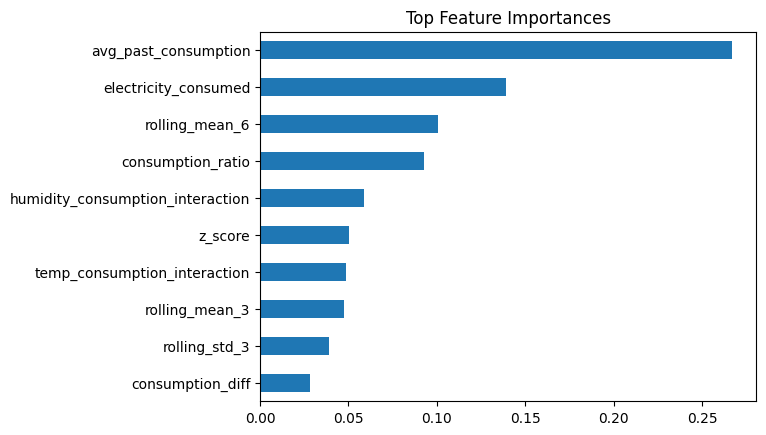

In [47]:
#FEATURE IMPORTANCE
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='barh')
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [49]:
#ISOLATION FOREST
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # adjust based on anomaly ratio
    random_state=42
)

iso_model.fit(X_train)

# Predict (-1 = anomaly, 1 = normal)
iso_preds = iso_model.predict(X_test)

# Convert to 0/1 format
# Isolation Forest returns -1 for anomalies and 1 for normal instances.
# Let's map -1 to 1 (Abnormal) and 1 to 0 (Normal) to align with standard binary classification output.
iso_preds = [1 if x == -1 else 0 for x in iso_preds]

# Convert y_test to numerical labels to match iso_preds
# Assuming 'Abnormal' corresponds to 1 and 'Normal' to 0
y_test_numeric = y_test.map({'Abnormal': 1, 'Normal': 0})

print("Isolation Forest Results:\n")
print(classification_report(y_test_numeric, iso_preds))

Isolation Forest Results:

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       944
           1       0.51      0.44      0.47        55

    accuracy                           0.95       999
   macro avg       0.74      0.71      0.72       999
weighted avg       0.94      0.95      0.94       999



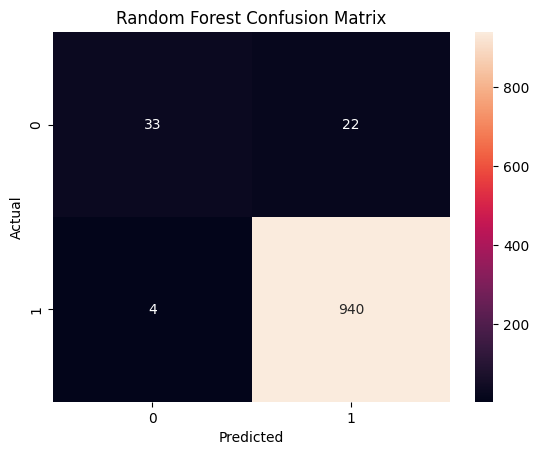

In [50]:
#CONFUSION MATRIX VISUALIZATION
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")

In [52]:
#PRECISION RECALL FOCUS
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(name, y_true, y_pred):
    print(f"{name} Performance:")
    # For string labels, specify the positive label
    if isinstance(y_true.iloc[0], str) or isinstance(y_pred[0], str):
        print("Precision:", precision_score(y_true, y_pred, pos_label='Abnormal'))
        print("Recall:", recall_score(y_true, y_pred, pos_label='Abnormal'))
        print("F1 Score:", f1_score(y_true, y_pred, pos_label='Abnormal'))
    else: # For numerical labels (like for Isolation Forest)
        print("Precision:", precision_score(y_true, y_pred))
        print("Recall:", recall_score(y_true, y_pred))
        print("F1 Score:", f1_score(y_true, y_pred))
    print("-"*40)

evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Isolation Forest", y_test_numeric, iso_preds)

Logistic Regression Performance:
Precision: 0.6666666666666666
Recall: 0.03636363636363636
F1 Score: 0.06896551724137931
----------------------------------------
Random Forest Performance:
Precision: 0.8918918918918919
Recall: 0.6
F1 Score: 0.717391304347826
----------------------------------------
Isolation Forest Performance:
Precision: 0.5106382978723404
Recall: 0.43636363636363634
F1 Score: 0.47058823529411764
----------------------------------------


In [54]:
#EARLY WARNING MODEL
# Shift target backward
df['anomaly_next'] = df['anomaly_label'].shift(-1)

df = df.dropna()

# Redefine splits
train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(columns=['anomaly_label', 'anomaly_next'])
y_train = train['anomaly_next']

X_test = test.drop(columns=['anomaly_label', 'anomaly_next'])
y_test = test['anomaly_next']

# Train model
rf_early = RandomForestClassifier(n_estimators=200, random_state=42)
rf_early.fit(X_train, y_train)

y_pred_early = rf_early.predict(X_test)

print("Early Warning Model:\n")
print(classification_report(y_test, y_pred_early))

Early Warning Model:

              precision    recall  f1-score   support

    Abnormal       0.64      0.16      0.26        55
      Normal       0.95      0.99      0.97       943

    accuracy                           0.95       998
   macro avg       0.80      0.58      0.62       998
weighted avg       0.94      0.95      0.93       998



In [55]:
#SHAP EXPLAINABILITY (Why anomalies occur)

In [56]:

!pip install shap

import shap

In [57]:
explainer = shap.TreeExplainer(rf_model)

# Use a subset for speed
X_sample = X_test.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

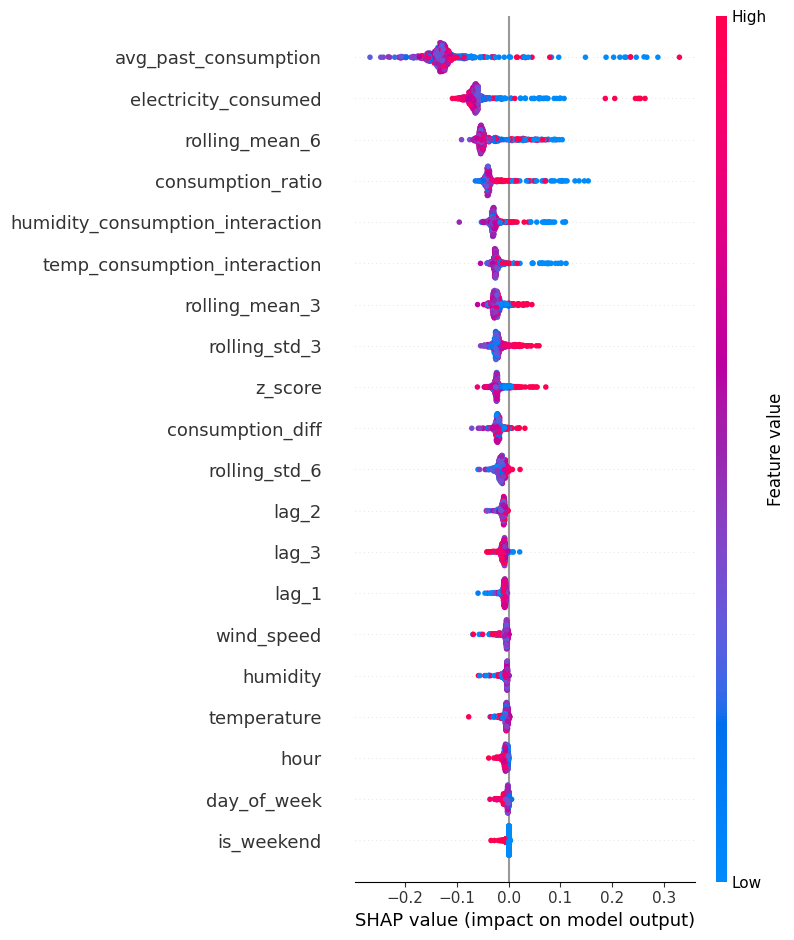

In [59]:
# Determine the index of the 'Abnormal' class
# Assuming rf_model.classes_ is ['Abnormal', 'Normal'] due to alphabetical sorting
# If it's ['Normal', 'Abnormal'], use index 1
abnormal_class_idx = list(rf_model.classes_).index('Abnormal')

shap.summary_plot(shap_values[:, :, abnormal_class_idx], X_sample)

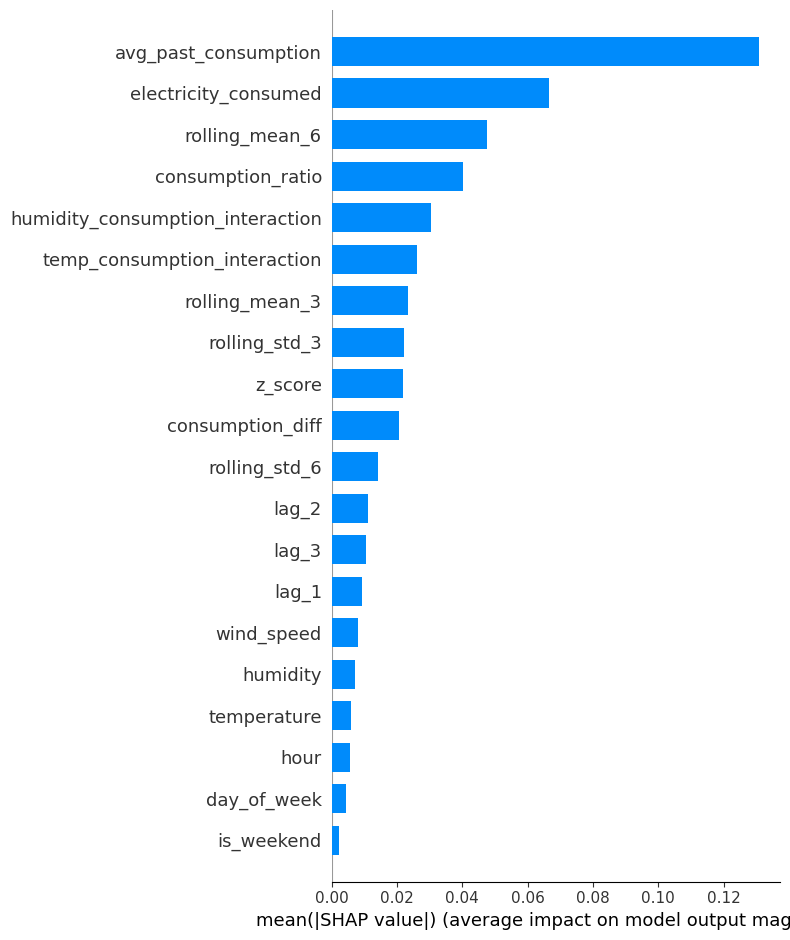

In [62]:
shap.summary_plot(shap_values[:, :, abnormal_class_idx], X_sample, plot_type="bar")

In [65]:
# Pick one anomaly case
anomaly_index = X_test[y_test == 'Abnormal'].index[0]

sample = X_test.loc[[anomaly_index]]

shap_values_single = explainer.shap_values(sample)

shap.force_plot(
    explainer.expected_value[abnormal_class_idx],
    shap_values_single[0][:, abnormal_class_idx],
    sample
)

In [66]:
import plotly.io as pio
pio.renderers.default = 'colab'

In [67]:
from google.colab import output
output.enable_custom_widget_manager()

In [70]:
# Pick one anomaly case
anomaly_index = X_test[y_test == 'Abnormal'].index[0]

sample = X_test.loc[[anomaly_index]]

shap_values_single = explainer.shap_values(sample)

shap.force_plot(
    explainer.expected_value[abnormal_class_idx],
    shap_values_single[0][:, abnormal_class_idx],
    sample
)

In [72]:
# predict() threshold = 0.5

In [73]:
y_probs = rf_model.predict_proba(X_test)[:, 1]

In [76]:
def evaluate_threshold(threshold):
    y_pred = (y_probs >= threshold).astype(int)

    # Convert y_test to numerical labels to match y_pred
    # Assuming 'Abnormal' corresponds to 1 and 'Normal' to 0
    y_test_numeric_for_eval = y_test.map({'Abnormal': 1, 'Normal': 0})

    from sklearn.metrics import precision_score, recall_score, f1_score

    precision = precision_score(y_test_numeric_for_eval, y_pred)
    recall = recall_score(y_test_numeric_for_eval, y_pred)
    f1 = f1_score(y_test_numeric_for_eval, y_pred)

    return precision, recall, f1

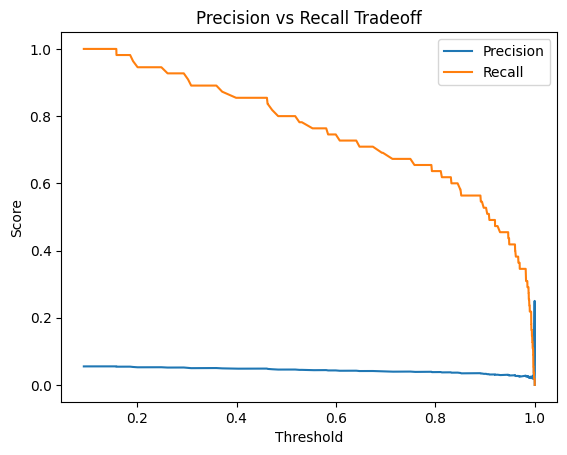

In [78]:
from sklearn.metrics import precision_recall_curve

# Convert y_test to numerical labels for precision_recall_curve
y_test_numeric_pr_curve = y_test.map({'Abnormal': 1, 'Normal': 0})

precision, recall, thresholds = precision_recall_curve(y_test_numeric_pr_curve, y_probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Tradeoff")
plt.legend()
plt.show()

In [79]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.4 MB/s eta 0:00:00


In [87]:
import streamlit as st
import pandas as pd
import joblib

# Load model and data
model = joblib.load("rf_model.pkl")
data = pd.read_csv("processed_data.csv")

# Ensure the timestamp column is correctly set as index, if applicable
# The processed_data.csv saved the index as a column named 'timestamp'
if 'timestamp' in data.columns:
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    data.set_index('timestamp', inplace=True)

st.title("Electricity Anomaly Detection Dashboard")

# Show data
st.subheader("Sample Data")
st.write(data.head())

# Select threshold
threshold = st.slider("Select Threshold", 0.0, 1.0, 0.3)

# Define the features that the rf_model was trained on
# This list should match the columns of X_train used during model training
feature_cols = [
    'electricity_consumed', 'temperature', 'humidity', 'wind_speed',
    'avg_past_consumption', 'hour', 'day_of_week', 'month', 'is_weekend',
    'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3',
    'rolling_mean_6', 'rolling_std_6', 'consumption_diff',
    'consumption_ratio', 'temp_consumption_interaction',
    'humidity_consumption_interaction', 'z_score'
]

# Prepare data for prediction: select only the features the model expects
X_predict = data[feature_cols]

# Predictions
probs = model.predict_proba(X_predict)[:, 1]
preds = (probs >= threshold).astype(int)

data['prediction'] = preds

# Show anomalies
st.subheader("Detected Anomalies")
st.write(data[data['prediction'] == 1])

2026-03-24 13:09:18.603 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:09:18.604 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:09:18.605 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:09:18.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:09:18.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:09:18.612 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:09:18.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:09:18.619 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [88]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']